# Work in progess...

In [1]:
import pandas as pd
import pyreadr
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
from darts.models import LinearRegressionModel

from itertools import product

from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from scipy import stats
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

/home/kuura/anaconda3/envs/nuwats_env/lib/python3.9/site-packages/statsforecast/utils.py:231: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  "ds": pd.date_range(start="1949-01-01", periods=len(AirPassengers), freq="M"),
The StatsForecast module could not be imported. To enable support for the StatsForecastAutoARIMA, StatsForecastAutoETS and Croston models, please consider installing it.


## Get era5 data and keep Fennoscandia

In [2]:
# get era5 data

era = pyreadr.read_r('../Data/era5_met.rds')[None]
era['date'] = pd.to_datetime(era['date'])
era['year'] = era['date'].dt.year
era['month'] = era['date'].dt.month

In [3]:
era

,station_id,date,tair,tp,sf,year,month
0,3_1,1960-01-01,270.935638,1.024788e-02,1.024122e-02,1960,1
1,3_1,1960-01-02,268.549255,8.457695e-03,8.453619e-03,1960,1
2,3_1,1960-01-03,265.638245,1.111615e-06,5.234033e-07,1960,1
3,3_1,1960-01-04,264.218536,1.451688e-05,1.340872e-05,1960,1
4,3_1,1960-01-05,265.721497,9.060125e-04,9.025466e-04,1960,1
...,...,...,...,...,...,...,...
28246037,1177_1,2024-06-26,287.689789,2.659548e-04,0.000000e+00,2024,6
28246038,1177_1,2024-06-27,285.414764,1.099903e-03,0.000000e+00,2024,6
28246039,1177_1,2024-06-28,284.358337,4.007968e-03,1.303852e-08,2024,6
28246040,1177_1,2024-06-29,286.996796,7.222891e-05,0.000000e+00,2024,6


In [4]:
lakes = pyreadr.read_r('../Data/ltbl_ice.rds')[None]
fs_lakes = set(lakes.loc[lakes['lon_wgs84'] > 0, 'station_id'].unique())
fin_lakes = set(lakes.loc[lakes['country'] == 'FI', 'station_id'].unique())

In [5]:
era = era.loc[era['station_id'].isin(fs_lakes), :]

## Trend analysis for ice data only

In [6]:
ice = pyreadr.read_r('../Data/data_ip.rds')[None]

ice['ice_on'] = pd.to_datetime(ice['ice_on'])
ice['ice_off'] = pd.to_datetime(ice['ice_off'])
ice['year'] = ice['year'].astype(int)

# keep fs lakes
ice = ice.loc[ice['station_id'].isin(fs_lakes), :]

# keep where both not null
ice = ice[ice[['ice_on', 'ice_off']].notnull().all(axis=1)]

# cut to same dates as in era and subset to same stations
ice = ice.loc[ice['ice_on'] >= era['date'].min(), :]
ice = ice.loc[ice['ice_off'] <= era['date'].max(), :]

/home/kuura/anaconda3/envs/nuwats_env/lib/python3.9/site-packages/pyreadr/_pyreadr_parser.py:233: RuntimeWarning: invalid value encountered in cast
  df[colname] = df[colname].values.astype("datetime64[D]").astype(datetime)
/home/kuura/anaconda3/envs/nuwats_env/lib/python3.9/site-packages/pyreadr/_pyreadr_parser.py:233: RuntimeWarning: invalid value encountered in cast
  df[colname] = df[colname].values.astype("datetime64[D]").astype(datetime)


### Group all time series by 4 year period bins and keep complete only

In [7]:
bins = pd.interval_range(start=ice['year'].min(), end=ice['year'].max(),
                        periods=4)
bins

IntervalIndex([(1960, 1976], (1976, 1992], (1992, 2008], (2008, 2024]], dtype='interval[int64, right]')

In [8]:
ice['bin'] = pd.cut(ice['year'], bins)
ice

,station_id,year,ice_on,ice_off,bin
11,3_1,1961,1960-11-01,1961-05-30,"(1960, 1976]"
12,3_1,1962,1961-11-28,1962-05-30,"(1960, 1976]"
13,3_1,1963,1962-11-18,1963-05-24,"(1960, 1976]"
14,3_1,1964,1963-11-12,1964-05-30,"(1960, 1976]"
15,3_1,1965,1964-11-09,1965-06-02,"(1960, 1976]"
...,...,...,...,...,...
31401,811_1,1982,1981-12-06,1982-04-06,"(1976, 1992]"
31402,811_1,1983,1982-12-10,1983-04-20,"(1976, 1992]"
31412,798_1,1961,1960-11-20,1961-05-15,"(1960, 1976]"
31417,798_1,1966,1965-11-13,1966-05-25,"(1960, 1976]"


In [9]:
def is_complete(_bin, group):
    # assume right interval
    
    years_in_group = set(group['year'].unique())
    years_in_bin = set(range(_bin.left+1, _bin.right+1))
    
    return len(years_in_bin.difference(years_in_group)) == 0

In [10]:
gb = ice.groupby([pd.cut(ice['year'], bins), 'station_id'])

n_complete = {}
complete_groups = []

for idx, (group_id, group_df) in enumerate(gb):
    _bin = group_df['bin'].iloc[0]
    
    if is_complete(_bin, group_df):
        complete_groups.append(group_df)
        try:
            n_complete[_bin] += 1
        except KeyError:
            n_complete[_bin] = 1
        
print(n_complete)

/tmp/ipykernel_2441/1424866502.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gb = ice.groupby([pd.cut(ice['year'], bins), 'station_id'])


{Interval(1960, 1976, closed='right'): 241, Interval(1976, 1992, closed='right'): 220, Interval(1992, 2008, closed='right'): 74, Interval(2008, 2024, closed='right'): 28}


In [11]:
ice = pd.concat(complete_groups)

In [12]:
ice['ice_on'] = pd.to_datetime(ice['ice_on'], format='%Y')
ice['ice_off'] = pd.to_datetime(ice['ice_off'], format='%Y')

#### Plot

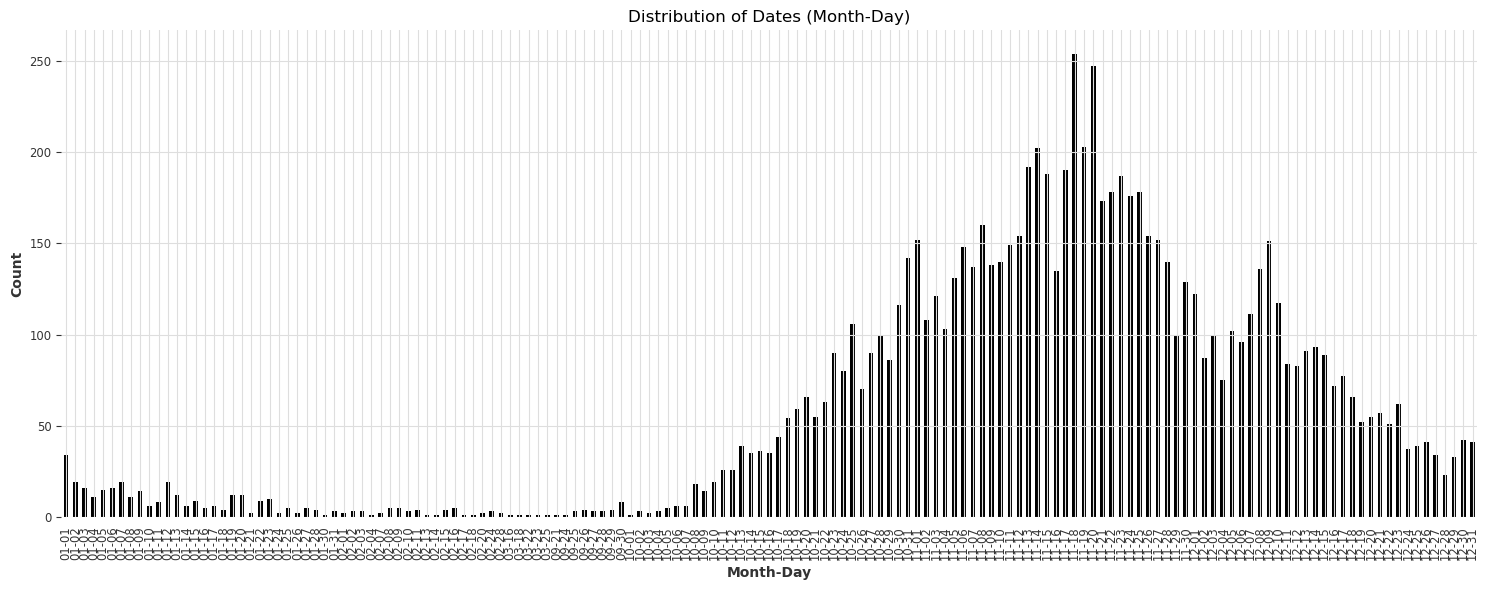

In [13]:
# what's the earliest ice_on?
month_days = ice['ice_on'].dt.strftime('%m-%d').value_counts().sort_index()

plt.figure(figsize=(15, 6))
month_days.plot(kind='bar')
plt.title('Distribution of Dates (Month-Day)')
plt.xlabel('Month-Day')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

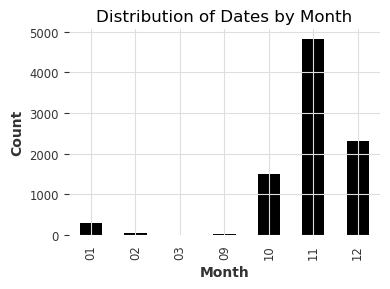

In [14]:
month_counts = ice['ice_on'].dt.strftime('%m').value_counts().sort_index()

plt.figure(figsize=(4, 3))
month_counts.plot(kind='bar')
plt.title('Distribution of Dates by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Data in the Northern hemisphere, calculate distance to 1st of January this year if ice on before April, to 1st Jan next year if after April. 

In [15]:
before_april = ice['ice_on'].dt.month < 4

ice['jan_1_current_year'] = pd.to_datetime(ice['ice_on'].dt.year.astype(str) + '-01-01')
ice['jan_1_next_year'] = pd.to_datetime((ice['ice_on'].dt.year + 1).astype(str) + '-01-01')

#ice['distance_to_jan_1'] = np.where(
#    before_april,
#    (ice['ice_on'] - ice['jan_1_current_year']).dt.days,
#    (ice['jan_1_next_year'] - ice['ice_on']).dt.days
#)

ice['distance_to_jan_1'] = np.where(
    before_april,
    (ice['jan_1_current_year'] - ice['ice_on']).dt.days,
    (ice['jan_1_next_year'] - ice['ice_on']).dt.days
)


# Drop intermediate columns if not needed
ice.drop(columns=['jan_1_current_year', 'jan_1_next_year'], inplace=True)

# ice['year_on_diff'] = (pd.to_datetime(ice['ice_on'], format='%Y') - pd.to_datetime(ice['ice_on'])).dt.days 
# ice

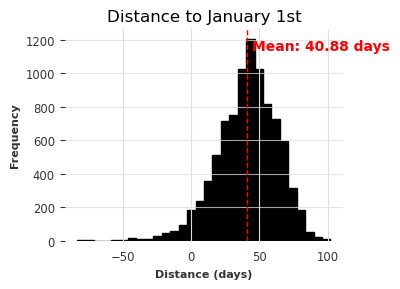

In [16]:
plt.figure(figsize=(4, 3))
plt.hist(ice['distance_to_jan_1'], bins=30, edgecolor='black')

# Customize the plot
plt.title('Distance to January 1st', fontsize=12)
plt.xlabel('Distance (days)', fontsize=8)
plt.ylabel('Frequency', fontsize=8)
plt.grid(axis='y', alpha=0.75)

# Add mean line
mean_distance = ice['distance_to_jan_1'].mean()
plt.axvline(mean_distance, color='red', linestyle='dashed', linewidth=1)
plt.text(mean_distance*1.1, plt.ylim()[1]*0.9, f'Mean: {mean_distance:.2f} days', 
         color='red', fontweight='bold')

# Show the plot
plt.tight_layout()
plt.show()

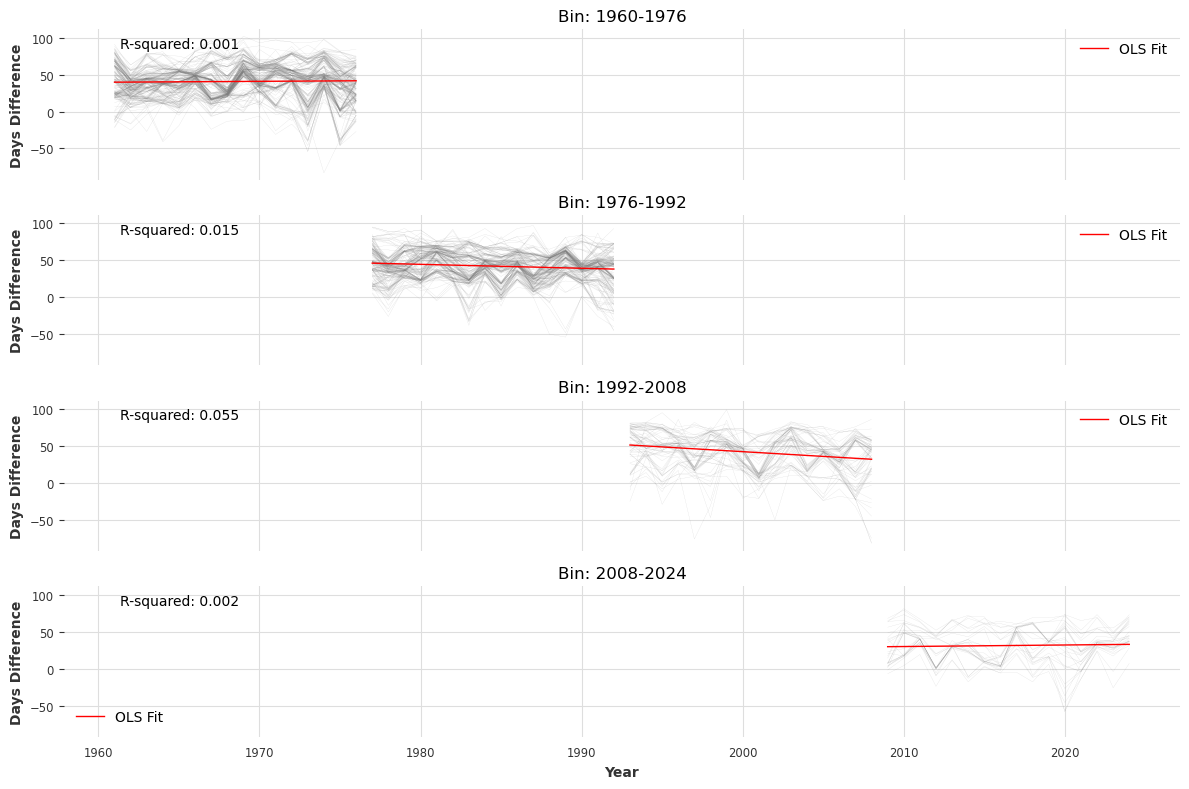

In [17]:
import statsmodels.api as sm

fig, axes = plt.subplots(len(bins), 1, figsize=(12, 8), sharex=True, sharey=True)

for i, bin_interval in enumerate(bins):
    ax = axes[i]
    bin_df = ice[ice['bin'] == bin_interval]
    
    for station_id in bin_df['station_id'].unique():
        station_df = bin_df[bin_df['station_id'] == station_id]
        
        # plot data
        ax.plot(station_df['year'], station_df['distance_to_jan_1'], 
                label='', color='gray', alpha=0.5, linewidth=0.1)

    # Make and plot OLS model
    
    # Prepare data for regression
    X = bin_df['year'].values 
    y = bin_df['distance_to_jan_1'].values
    
    # Add constant and squared term for polynomial regression
    # X = sm.add_constant(np.column_stack((X, X**2)))
    X = sm.add_constant(X)
    
    # Fit the model
    model = sm.OLS(y, X).fit()
    
    # Generate predictions
    x_smooth = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
    # X_pred = sm.add_constant(np.column_stack((x_smooth, x_smooth**2)))
    X_pred = sm.add_constant(x_smooth)
    y_pred = model.predict(X_pred)

    ax.plot(x_smooth, y_pred, color='red', linewidth=1, 
            label='OLS Fit')

    # Add R-squared value to the plot
    ax.text(0.05, 0.95, f'R-squared: {model.rsquared:.3f}', 
            transform=ax.transAxes, 
            verticalalignment='top')

    
    ax.set_title(f'Bin: {bin_interval.left}-{bin_interval.right}')
    ax.set_ylabel('Days Difference')
    ax.legend()

plt.xlabel('Year')
plt.tight_layout()



### Box-plots

In [18]:
# Group data by bins
box_data = [ice[ice['bin'] == bin_interval]['distance_to_jan_1'] for bin_interval in bins]

# Perform one-way ANOVA
f_stat, p_value = f_oneway(*box_data)
print(f"ANOVA F-statistic: {f_stat:.2f}, p-value: {p_value:.4f}")

# Perform Tukey's HSD post-hoc test if ANOVA is significant
if p_value < 0.05:
    # Create a DataFrame for Tukey's HSD
    tukey_data = pd.DataFrame({
        'distance_to_jan_1': ice['distance_to_jan_1'],
        'bin': ice['bin'].apply(lambda x: f'{x.left}-{x.right}')
    })
    
    tukey_result = pairwise_tukeyhsd(tukey_data['distance_to_jan_1'], tukey_data['bin'])
    print(tukey_result)

    # Extract group labels from Tukey's HSD results
    group_labels = {group: label for group, label in zip(tukey_result.groupsunique, tukey_result._results_table.data[1:])}
else:
    print("No significant differences found between groups.")
    group_labels = {f'{bin_interval.left}-{bin_interval.right}': 'a' for bin_interval in bins}



ANOVA F-statistic: 34.10, p-value: 0.0000
    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
  group1    group2  meandiff p-adj   lower    upper  reject
-----------------------------------------------------------
1960-1976 1976-1992    1.432 0.0241   0.1319  2.7321   True
1960-1976 1992-2008   0.9562 0.5464  -0.8969  2.8092  False
1960-1976 2008-2024  -9.4858    0.0 -12.2696  -6.702   True
1976-1992 1992-2008  -0.4759 0.9147  -2.3495  1.3978  False
1976-1992 2008-2024 -10.9178    0.0 -13.7154 -8.1202   True
1992-2008 2008-2024  -10.442    0.0 -13.5355 -7.3484   True
-----------------------------------------------------------


In [19]:
# https://github.com/timyerg/cld4py/blob/main/cld4py/cld4py.py
import string

def assign_letters(df, G1, G2, P, alpha=.05,
           order=None, data=None, vals=None, group=None, param=True):
    """
    Function to apply compact letter display for pairwise contrasts.
    Groups with no significant differences share a letter.
    
    Parameters:
    
      Required:
        df    - dataframe with contrasts (pairwise comparisons).
        G1, G2 - columns in contrasts df with compared groups.
        P      - column in contrasts df with p-value (adjusted, right?).
        
      Optional:
        alpha  - sigificance level (default 0.05).
        order  - None (default), list or ['ascending', 'descending'].
                 This parameter will define the order of assigned letters.
                 None - alphabetical order will be applied.
                 List - order of groups will be defined by that list.
                 String 'ascending' or 'descending' requires parameters
                 'data', 'values' and 'group' to order groups by the mean.
        data   - dataframe with values that were compared to get contrasts.
        vals   - column in data with compared values.
        group  - column in data with group information.
        param  - wether sort by mean (True; default) or median (False).
    """
    
    #helper function to check p
    def is_sign(lv1, lv2, df=df, alpha=alpha):
        return df.loc[(df[G1]==lv1)&(df[G2]==lv2)|(df[G1]==lv2)&(df[G2]==lv1),P].iloc[0] < alpha
          
    letters = string.ascii_lowercase
    df[P] = df[P].apply(pd.to_numeric)
    
    #define order
    if order == None:
        order = sorted(set(df[G1].tolist() + df[G2].tolist()))
    if order in ['ascending', 'descending']:
        asc = order=='ascending'
        data[vals] = data[vals].apply(pd.to_numeric)
        if param:
            order = pd.DataFrame(data.groupby(group)[vals].mean()).sort_values(vals, ascending=asc).index.tolist()
        else:
            order = pd.DataFrame(data.groupby(group)[vals].median()).sort_values(vals, ascending=asc).index.tolist()
    #assign letters
    draft, sets = {}, []
    for i, l1 in enumerate(order):
        draft.update({i: {l1}})
        for l2 in order: 
            if l1 != l2 and not any([is_sign(l1,l2)]+[is_sign(l,l2) for l in draft[i]]):
                    draft[i].add(l2)
    [sets.append(v) for v in draft.values() if v not in sets]
    cld = pd.DataFrame(columns=['Group', 'Letters'])
    for i,l in enumerate(order):
        cld.loc[i, ['Group', 'Letters']] = l, ''.join([letters[j] for j,s in enumerate(sets) if l in s])
    return cld.set_index('Group')

In [20]:
df = pd.DataFrame(tukey_result._results_table.data)
df.columns = df.iloc[0]
df = df.drop(df.index[0])

group_labels = assign_letters(df, 'group1', 'group2', 'p-adj').to_dict()['Letters']

In [21]:
def validate_labels(group_labels, tukey_results):
    df = pd.DataFrame(tukey_result._results_table.data)
    df.columns = df.iloc[0]
    df = df.drop(df.index[0])
    # print(df)
    
    groups = list(group_labels.keys())
    
    for g1, g2 in zip(groups[:-1], groups[1:]):
        rej = df.loc[(df['group1'] == g1) & (df['group2'] == g2), 'reject'].values[0]
        # print(f'{g1} {g2} {rej}')

        if rej == True:
            #print(set(group_labels[g1]))
            #print(set(group_labels[g2]))
            #print(set(group_labels[g1]).intersection(set(group_labels[g1])))
            assert len(set(group_labels[g1]).intersection(set(group_labels[g2]))) == 0

validate_labels(group_labels, tukey_result)
        

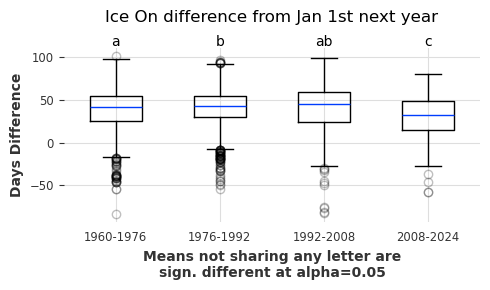

In [22]:
# Plot box plots with significance labels https://github.com/timyerg/cld4py/blob/main/cld4py/cld4py.py

fig, ax = plt.subplots(figsize=(5, 3))

positions = range(1, len(bins) + 1)

box_plot = ax.boxplot(box_data, positions=positions, widths=0.5)

for flier in box_plot['fliers']:
    flier.set(marker='o', 
              markerfacecolor='none',
              markeredgecolor='black', 
              alpha=0.25,
              markersize=6)

# Set x-tick labels to bin ranges
ax.set_xticks(positions)
ax.set_xticklabels([f'{bin_interval.left}-{bin_interval.right}' for bin_interval in bins])

# Add significance labels above each box plot
for i, bin_interval in enumerate(bins):
    label = group_labels.get(f'{bin_interval.left}-{bin_interval.right}', 'NA')
    ax.text(positions[i], 110, # max(box_data) + 0.5
            label,
            horizontalalignment='center', verticalalignment='bottom')

ax.set_xlabel('Means not sharing any letter are\nsign. different at alpha=0.05')
ax.set_ylabel('Days Difference')
ax.set_title('Ice On difference from Jan 1st next year\n')

plt.tight_layout()
plt.show()


### Ice on trends with Darts and univariate clustering

In [23]:
ice.dtypes

station_id                   object
year                          int64
ice_on               datetime64[ns]
ice_off              datetime64[ns]
bin                        category
distance_to_jan_1             int64
dtype: object

In [24]:
grouped = ice.groupby(['station_id', 'bin'])

time_series_dict = {}
for (station_id, bin_label), group in grouped:
    ts = TimeSeries.from_dataframe(
        group,
        time_col='year',
        value_cols='distance_to_jan_1',
    )
    time_series_dict[(station_id, bin_label)] = ts


/tmp/ipykernel_2441/1238373440.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = ice.groupby(['station_id', 'bin'])


In [25]:
# Normalize the time series (optional but recommended)
scaler = Scaler()
scaled_time_series_dict = {
    key: scaler.fit_transform(ts) for key, ts in time_series_dict.items()
}

# Fit a linear regression model to detect trends for each time series
trend_dict = {}
for key, ts in scaled_time_series_dict.items():
    model = LinearRegressionModel(lags=12)
    model.fit(ts)
    prediction = model.predict(len(ts))
    trend_dict[key] = prediction

# Print trends for station and bin
# for key, trend in trend_dict.items():
    # print(f"Trend for {key}: {trend}")

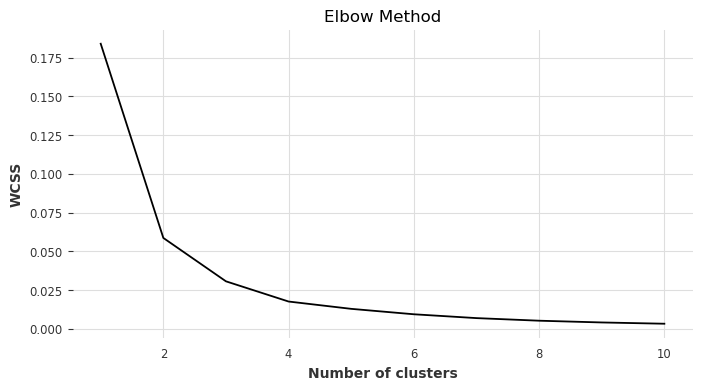

In [26]:
# Extract slopes of trends as features for clustering
slopes = []
keys = []
for key, ts in scaled_time_series_dict.items():
    keys.append(key)
    x = np.arange(len(ts.values()))
    y = ts.values().flatten()
    slope, _ = np.polyfit(x, y, 1)  # Linear fit to get slope
    slopes.append(slope)

# Convert slopes to a numpy array
X = np.array(slopes).reshape(-1, 1)

# Perform elbow method to find optimal number of clusters
# wcss == within cluster sum of squares
wcss = []
max_clusters = 10  # You can adjust this value
for i in range(1, max_clusters + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, max_clusters + 1), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [27]:
# Extract slopes of trends as features for clustering
slopes = []
keys = []
for key, ts in scaled_time_series_dict.items():
    keys.append(key)
    x = np.arange(len(ts.values()))
    y = ts.values().flatten()
    slope, _ = np.polyfit(x, y, 1)  # Linear fit to get slope
    slopes.append(slope)

kmeans = KMeans(n_clusters=3, random_state=42) 
clusters = kmeans.fit_predict(np.array(slopes).reshape(-1, 1))

# Map clusters back to keys (station_id, bin)
cluster_results = pd.DataFrame({'key': keys, 'cluster': clusters})

print(cluster_results)

                       key  cluster
0    (104_1, (1976, 1992])        2
1    (107_1, (1976, 1992])        0
2    (114_1, (1960, 1976])        2
3    (114_1, (1976, 1992])        0
4    (116_1, (1960, 1976])        2
..                     ...      ...
558   (91_1, (1960, 1976])        1
559   (93_1, (1976, 1992])        2
560   (94_1, (1960, 1976])        2
561   (96_1, (1960, 1976])        0
562   (97_1, (1960, 1976])        1

[563 rows x 2 columns]


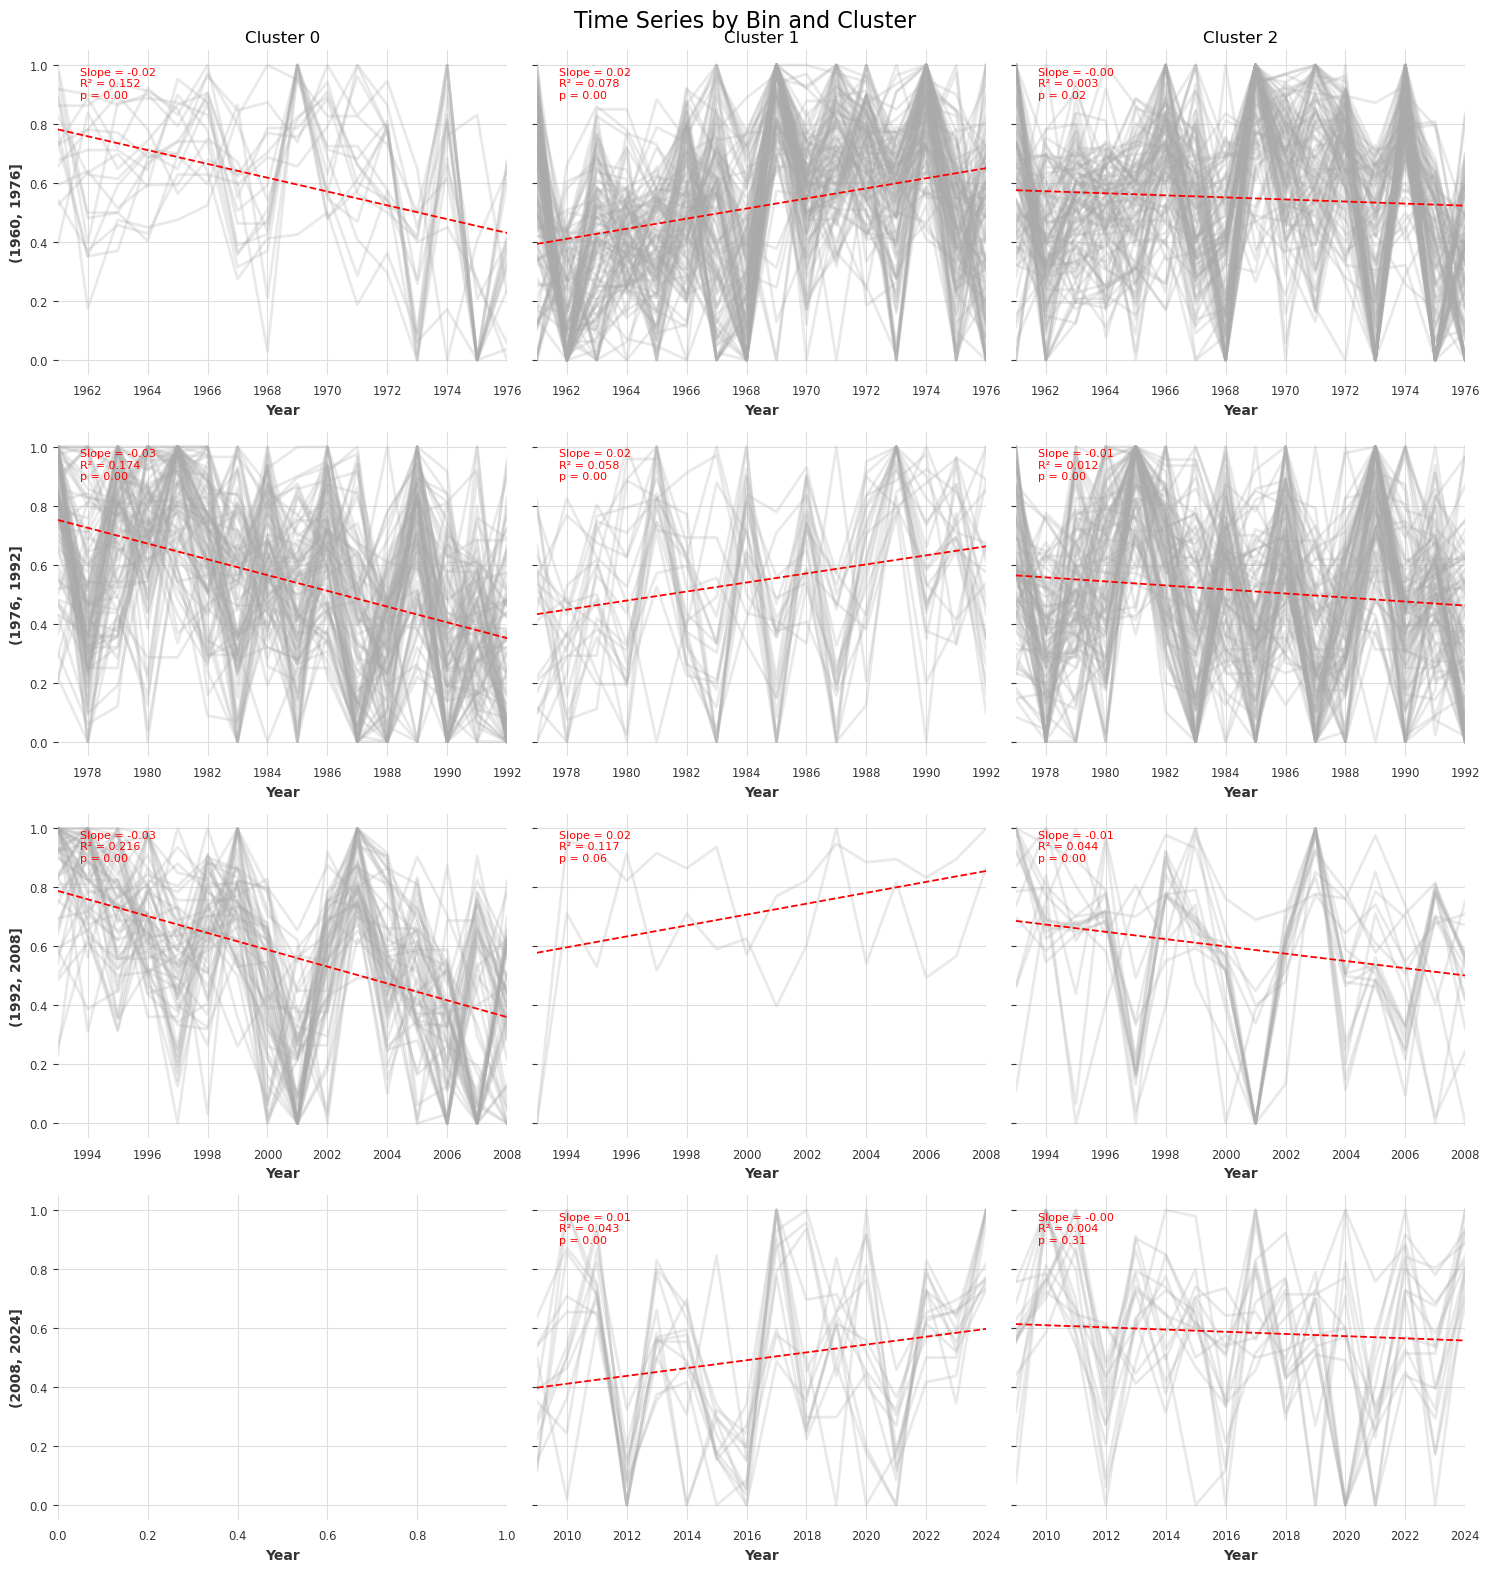

In [28]:
import warnings
warnings.filterwarnings('ignore')

# Get unique bins and clusters
unique_bins = sorted(set(key[1] for key in time_series_dict.keys()))
unique_clusters = sorted(cluster_results['cluster'].unique())

# Set up the plot grid
n_rows = len(unique_bins)
n_cols = len(unique_clusters)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows), sharex=False, sharey=True)
fig.suptitle("Time Series by Bin and Cluster", fontsize=16)

# Plot time series for each bin and cluster
for (row, bin_label), (col, cluster) in product(enumerate(unique_bins), enumerate(unique_clusters)):
    ax = axes[row, col]
    
    # Filter time series for this bin and cluster
    cluster_keys = cluster_results[(cluster_results['cluster'] == cluster) & 
                                   (cluster_results['key'].apply(lambda x: x[1] == bin_label))]['key']
    
    all_x = []
    all_y = []
    
    for i, key in enumerate(cluster_keys):
        ts = scaled_time_series_dict[key]
        ts.plot(ax=ax, label=None, color="#aaaaaa", alpha=0.25)
        
        # Collect all x and y values for linear regression
        all_x.extend(ts.time_index.values)
        all_y.extend(ts.values().flatten())
    
    # Perform linear regression if we have data
    if all_x and all_y:
        slope, intercept, r_value, p_value, _ = stats.linregress(all_x, all_y)
        r_squared = r_value**2
        
        # Plot the linear fit
        x_range = np.array([min(all_x), max(all_x)])
        ax.plot(x_range, slope * x_range + intercept, color='red', linestyle='--')
        
        # Add R-squared value to the plot
        # ax.text(0.05, 0.95, f'R² = {r_squared:.3f}', transform=ax.transAxes, 
        #         verticalalignment='top', fontsize=10, color='red')
        ax.text(0.05, 0.95, f'Slope = {slope:.2f}\nR² = {r_squared:.3f}\np = {p_value:.2f}', 
                transform=ax.transAxes, 
                verticalalignment='top', fontsize=8, color='red')
    
    # Set titles and labels
    if row == 0:
        ax.set_title(f"Cluster {cluster}")
    if col == 0:
        ax.set_ylabel(bin_label)
    
    ax.set_xlabel("Year")
    
    # Adjust x-axis to fill the panel
    if all_x:
        ax.set_xlim(min(all_x), max(all_x))
    
    # Remove legend
    ax.legend().remove()

# Adjust layout and display
plt.tight_layout()
plt.show()


## Combine with ERA5 and lake data for finer analysis

In [29]:
# Group by station, year, and month, then calculate the mean for temperature and wind
aggregated_era = era.groupby(['station_id', 'year']).agg({
    'tair': 'mean',
    'tp': 'mean',
    'sf': 'mean'
}).reset_index()

# Drop the separate year and month columns
aggregated_era = aggregated_era.sort_values(['station_id', 'year'])

aggregated_era

,station_id,year,tair,tp,sf
0,101_1,1960,278.824476,0.002087,0.000507
1,101_1,1961,279.455217,0.001905,0.000288
2,101_1,1962,277.403398,0.001705,0.000443
3,101_1,1963,278.095886,0.001748,0.000301
4,101_1,1964,278.895031,0.001386,0.000222
...,...,...,...,...,...
56415,9_1,2020,281.249412,0.002093,0.000200
56416,9_1,2021,279.848745,0.002199,0.000414
56417,9_1,2022,280.532994,0.001755,0.000390
56418,9_1,2023,280.213913,0.002366,0.000516


In [30]:
ice_era = ice.merge(aggregated_era, on=['station_id', 'year'], how='left')
ice_era_stats = ice_era.merge(lakes, on=['station_id'])

del ice_era

In [31]:
ice_era_stats

,station_id,year,ice_on,ice_off,bin,distance_to_jan_1,tair,tp,sf,lake_id,...,subset,lake_name,lat_wgs84,lon_wgs84,altitude_m,area_ha,depth_mean_m,depth_max_m,cent_lat_wgs84,cent_lon_wgs84
0,114_1,1961,1960-10-25,1961-06-01,"(1960, 1976]",68,274.366376,0.003106,0.001242,114,...,NaN,Gevsjön,63.396441,12.634258,499.2,1116.01,11.9,31.6,63.378048,12.650479
1,114_1,1962,1961-11-26,1962-05-31,"(1960, 1976]",36,272.563554,0.002672,0.001160,114,...,NaN,Gevsjön,63.396441,12.634258,499.2,1116.01,11.9,31.6,63.378048,12.650479
2,114_1,1963,1962-11-12,1963-05-18,"(1960, 1976]",50,273.775926,0.002486,0.001193,114,...,NaN,Gevsjön,63.396441,12.634258,499.2,1116.01,11.9,31.6,63.378048,12.650479
3,114_1,1964,1963-11-06,1964-05-21,"(1960, 1976]",56,274.005391,0.003012,0.001245,114,...,NaN,Gevsjön,63.396441,12.634258,499.2,1116.01,11.9,31.6,63.378048,12.650479
4,114_1,1965,1964-11-12,1965-05-27,"(1960, 1976]",50,273.060681,0.002554,0.001174,114,...,NaN,Gevsjön,63.396441,12.634258,499.2,1116.01,11.9,31.6,63.378048,12.650479
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9003,726_1,2020,2019-10-22,2020-06-03,"(2008, 2024]",71,273.141063,0.001768,0.000930,726,...,NaN,"Kevojärvi, Kevoniemi",69.756589,27.003159,75.0,102.00,11.1,35.0,69.758970,27.000790
9004,726_1,2021,2020-11-10,2021-05-29,"(2008, 2024]",52,272.011964,0.001496,0.000730,726,...,NaN,"Kevojärvi, Kevoniemi",69.756589,27.003159,75.0,102.00,11.1,35.0,69.758970,27.000790
9005,726_1,2022,2021-10-20,2022-05-25,"(2008, 2024]",73,273.223573,0.001782,0.000668,726,...,NaN,"Kevojärvi, Kevoniemi",69.756589,27.003159,75.0,102.00,11.1,35.0,69.758970,27.000790
9006,726_1,2023,2022-11-12,2023-05-21,"(2008, 2024]",50,272.671570,0.001599,0.000651,726,...,NaN,"Kevojärvi, Kevoniemi",69.756589,27.003159,75.0,102.00,11.1,35.0,69.758970,27.000790


In [32]:
cluster_results.loc[cluster_results['key'].map(lambda x: x[0] == '114_1'), :]['key'][2]

('114_1', Interval(1960, 1976, closed='right'))

In [33]:
# cluster_results[('114_1', pd.Interval(1960, 1976, closed='right'))]
cluster_results['_key'] = cluster_results['key'].map(lambda x: (x[0], str(x[1])))
cluster_results

,key,cluster,_key
0,"(104_1, (1976, 1992])",2,"(104_1, (1976, 1992])"
1,"(107_1, (1976, 1992])",0,"(107_1, (1976, 1992])"
2,"(114_1, (1960, 1976])",2,"(114_1, (1960, 1976])"
3,"(114_1, (1976, 1992])",0,"(114_1, (1976, 1992])"
4,"(116_1, (1960, 1976])",2,"(116_1, (1960, 1976])"
...,...,...,...
558,"(91_1, (1960, 1976])",1,"(91_1, (1960, 1976])"
559,"(93_1, (1976, 1992])",2,"(93_1, (1976, 1992])"
560,"(94_1, (1960, 1976])",2,"(94_1, (1960, 1976])"
561,"(96_1, (1960, 1976])",0,"(96_1, (1960, 1976])"


In [34]:
# ice_era_stats[['station_id', 'bin']].apply(lambda x: cluster_results.loc[cluster_results['key'] == (x[0], x[1]), 'cluster'][0])
ice_era_stats['_key'] = ice_era_stats[['station_id', 'bin']].apply(lambda x: (x[0], str(x[1])), axis=1)

In [35]:
ice_era_stats = ice_era_stats.merge(cluster_results, on=['_key'])
ice_era_stats.drop(columns=['_key', 'key'], inplace=True)
ice_era_stats

,station_id,year,ice_on,ice_off,bin,distance_to_jan_1,tair,tp,sf,lake_id,...,lake_name,lat_wgs84,lon_wgs84,altitude_m,area_ha,depth_mean_m,depth_max_m,cent_lat_wgs84,cent_lon_wgs84,cluster
0,114_1,1961,1960-10-25,1961-06-01,"(1960, 1976]",68,274.366376,0.003106,0.001242,114,...,Gevsjön,63.396441,12.634258,499.2,1116.01,11.9,31.6,63.378048,12.650479,2
1,114_1,1962,1961-11-26,1962-05-31,"(1960, 1976]",36,272.563554,0.002672,0.001160,114,...,Gevsjön,63.396441,12.634258,499.2,1116.01,11.9,31.6,63.378048,12.650479,2
2,114_1,1963,1962-11-12,1963-05-18,"(1960, 1976]",50,273.775926,0.002486,0.001193,114,...,Gevsjön,63.396441,12.634258,499.2,1116.01,11.9,31.6,63.378048,12.650479,2
3,114_1,1964,1963-11-06,1964-05-21,"(1960, 1976]",56,274.005391,0.003012,0.001245,114,...,Gevsjön,63.396441,12.634258,499.2,1116.01,11.9,31.6,63.378048,12.650479,2
4,114_1,1965,1964-11-12,1965-05-27,"(1960, 1976]",50,273.060681,0.002554,0.001174,114,...,Gevsjön,63.396441,12.634258,499.2,1116.01,11.9,31.6,63.378048,12.650479,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9003,726_1,2020,2019-10-22,2020-06-03,"(2008, 2024]",71,273.141063,0.001768,0.000930,726,...,"Kevojärvi, Kevoniemi",69.756589,27.003159,75.0,102.00,11.1,35.0,69.758970,27.000790,2
9004,726_1,2021,2020-11-10,2021-05-29,"(2008, 2024]",52,272.011964,0.001496,0.000730,726,...,"Kevojärvi, Kevoniemi",69.756589,27.003159,75.0,102.00,11.1,35.0,69.758970,27.000790,2
9005,726_1,2022,2021-10-20,2022-05-25,"(2008, 2024]",73,273.223573,0.001782,0.000668,726,...,"Kevojärvi, Kevoniemi",69.756589,27.003159,75.0,102.00,11.1,35.0,69.758970,27.000790,2
9006,726_1,2023,2022-11-12,2023-05-21,"(2008, 2024]",50,272.671570,0.001599,0.000651,726,...,"Kevojärvi, Kevoniemi",69.756589,27.003159,75.0,102.00,11.1,35.0,69.758970,27.000790,2


In [36]:
ice_era_stats['cluster'].unique()

array([2, 1, 0], dtype=int32)

In [37]:
# map for static series

station_to_statics = {}

for _, row in lakes.groupby('station_id').first().reset_index().iterrows():
    station_to_statics[row['station_id']] = pd.Series({
        # 'station_id': row['station_id'],
        'lat_wgs84': row['lat_wgs84'],
        'lon_wgs84': row['lon_wgs84'],
        'altitude_m': row['altitude_m'],
        'area_ha': row['area_ha'],
        'depth_mean_m': row['depth_mean_m'],
        'depth_max_m': row['depth_max_m']
    })

station_to_statics[ice_era_stats['station_id'][0]]
          

lat_wgs84         63.396441
lon_wgs84         12.634258
altitude_m       499.200000
area_ha         1116.010000
depth_mean_m      11.900000
depth_max_m       31.600000
dtype: float64

In [38]:
ts_binned = {}

for (station, _bin), group in ice_era_stats.groupby(['station_id', 'bin']):
    # Sort by date and reset index
    group = group.sort_values('year').reset_index(drop=True)

    ts = TimeSeries.from_dataframe(
        group,
        time_col='year',
        value_cols=['tair', 'tp', 'sf', 'distance_to_jan_1', 'cluster'],
        static_covariates=station_to_statics[group['station_id'][0]])

    try:
        ts_binned[_bin].append(ts)
    except KeyError:
        ts_binned[_bin] = [ts]


In [39]:
ts_binned.keys()

dict_keys([Interval(1976, 1992, closed='right'), Interval(1960, 1976, closed='right'), Interval(1992, 2008, closed='right'), Interval(2008, 2024, closed='right')])

### TODO: transform (incl area), scale

In [40]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
scaler = Scaler(scaler, global_fit=True)

n_test = 3  # years

_ts_data = ts_binned[pd.Interval(1976, 1992, closed='right')]

[scaler.fit(s[:-n_test]) for s in _ts_data]

train_ts = [scaler.transform(s[:-n_test]) for s in _ts_data]
test_ts  = [scaler.transform(s[-n_test:]) for s in _ts_data]


In [41]:
from darts.models import RandomForest
from darts.timeseries import concatenate

model = RandomForest(lags=[-1], lags_past_covariates=[-1])

model.fit(
    series=[s['cluster'] for s in train_ts],
    past_covariates=[concatenate([s['tair'], s['sf'], s['tp']], axis=1) for s in train_ts])

RandomForest(lags=[-1], lags_past_covariates=[-1], lags_future_covariates=None, output_chunk_length=1, output_chunk_shift=0, add_encoders=None, n_estimators=100, max_depth=None, multi_models=True, use_static_covariates=True)